# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

<font color="MidnightBlue">The goal of this analisys is to find which features of the dataset have the greatest impact on the price of a used car.</font>

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

<font color="MidnightBlue">I want to see the first 5 rows to have an idea what kind of columns the dataset has and run .info() to see the datatypes. As we can see, there are typical car features like paint color, fuel and cylinderd etc. And the df contains primerly string data type</font>

In [1265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.feature_selection import SequentialFeatureSelector



df = pd.read_csv("./data/vehicles.csv")
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [1266]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

<font color="MidnightBlue"> Now I want to explore the missing data. </font>

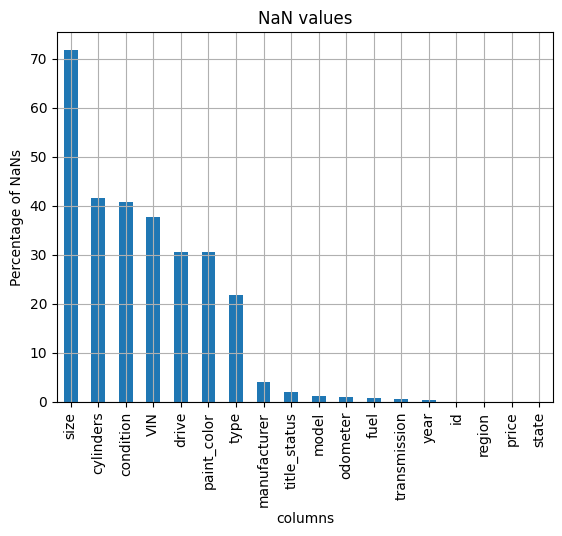

In [1267]:
nan_counts = df.isna().sum().sort_values(ascending=False)
nan_counts = (nan_counts / df.shape[0]) * 100
nan_counts.plot(kind='bar')
plt.title("NaN values")
plt.ylabel("Percentage of NaNs")
plt.xlabel("columns")
plt.grid(True)
plt.show()


<font color="MidnightBlue"> 70% of the "size" column are missing and almost a half of the information about cylinders and condition are missing, and more thån a third information for VIN.
I want to explore the missing data and see what I can do about it. First, I want to check how size column looks like.
Briefly looking at the notnull "sizes", I saw that this data is categorical, so maybe I can find the model or manufacturer information and fillup the missing size information for the similar models/makes.
</font>

In [1268]:
df[~df["size"].isna()][["manufacturer", "model", "size"]]

,manufacturer,model,size
31,ford,f-150 xlt,full-size
46,jeep,compass,full-size
55,ford,f250 super duty,full-size
59,honda,odyssey,full-size
65,ford,f450,full-size
...,...,...,...
426809,jeep,gand wagoneer,full-size
426831,nissan,300zx coupe with t-tops,sub-compact
426833,jaguar,xk8 convertible,compact
426836,ram,2500,full-size


In [1269]:
df.groupby("model")["size"].nunique().sort_values(ascending=False)

model
explorer                       4
fit                            4
fusion se                      4
wrx                            4
challenger                     4
                              ..
e350 14 passenger van          0
e350 12' box van               0
e350 12' box truck             0
e320 4matic                    0
🔥GMC Sierra 1500 SLE🔥 4X4 🔥    0
Name: size, Length: 29649, dtype: int64

<font color="MidnightBlue"> The information above how mayne unique size values each model has. For example, explorer can have 4 different sizes. In addition to that we see that the model column contains some messy data </font>

In [1270]:
df[(df["model"].isin(["explorer", "fit", "fusion se", "wrx", "challenger"])) & (~df["size"].isna())][["model", "manufacturer", "size", "type", "year"]]

,model,manufacturer,size,type,year
2090,fusion se,ford,full-size,sedan,2013.0
2196,explorer,ford,mid-size,SUV,2013.0
2222,explorer,ford,mid-size,SUV,2016.0
3835,explorer,ford,full-size,SUV,2018.0
3934,explorer,ford,full-size,SUV,2016.0
...,...,...,...,...,...
424172,fusion se,ford,mid-size,sedan,2010.0
424918,explorer,ford,full-size,pickup,2015.0
425133,fusion se,ford,mid-size,sedan,2012.0
425444,explorer,ford,full-size,SUV,2013.0


<font color="MidnightBlue"> However, this result shows that some model names can have different sizes. I am so bad with cars, I know nothing about them. So maybe the type will help.  </font>

<font color = "MidnightBlue">Nope, type hasn't help. I briefly looked up at SUVs ads an example, they can be of sizes. What if I try to group by combination of features and see of the size will be unique.  </font>

In [1271]:
df.groupby(["manufacturer", "model", "year", "type"])["size"].nunique().sort_values(ascending=False)


manufacturer  model                       year    type       
ford          mustang                     2012.0  coupe          4
              fiesta                      2011.0  sedan          4
              mustang                     1996.0  coupe          4
                                          2004.0  convertible    4
                                          2006.0  coupe          4
                                                                ..
gmc           sierra duramax 2500 hd 4x4  2017.0  truck          0
                                          2020.0  truck          0
              sierra duramax 2500 hd all  2015.0  truck          0
              sierra duramax 2500 hd at4  2020.0  truck          0
volvo         xc90t6 awd 24733 miles      2018.0  SUV            0
Name: size, Length: 59215, dtype: int64

<font color="MidnightBlue"> Here I am just looking at a example of such data, in addition checking how cylinder info looks like </font>

In [1272]:
df[(df["model"] == "mustang") & (df["year"] == 2011.0) & (df["type"] == "coupe") & (df["size"].notna())][["size", "manufacturer", "cylinders"]]

,size,manufacturer,cylinders
107166,mid-size,ford,6 cylinders
242844,compact,ford,8 cylinders
347814,full-size,ford,6 cylinders
366024,sub-compact,ford,8 cylinders


<font color = "Midnightblue"> So my hypothesis did not work out, it is possible to have different sizes for the cars even if they have the same model name, year and type, and make. But I cannot get rid of the 70% percent of data. Maybe I will replace the size with the most common for a particluar model and year. But now I will move to the cylinder column exploration, maybe I will have more insights about sizes and will have a better idea.

</font>

In [1273]:
df.groupby(["manufacturer", "model", "year", "fuel", "type"])["cylinders"].nunique().sort_values(ascending=False)

manufacturer   model                   year    fuel   type 
honda          accord                  2004.0  gas    coupe    4
bmw            5 series                2014.0  gas    sedan    4
honda          civic                   2010.0  gas    sedan    4
jeep           cherokee                2016.0  gas    SUV      4
ford           escape                  2020.0  gas    SUV      4
                                                              ..
chrysler       pt crusier              2007.0  gas    wagon    0
mercedes-benz  e-class e 300           2018.0  other  sedan    0
                                               gas    sedan    0
                                       2017.0  gas    sedan    0
volvo          xc90t6 awd 24733 miles  2018.0  gas    SUV      0
Name: cylinders, Length: 63075, dtype: int64

In [1274]:
df[(df["model"] == "accord") & (df["year"] == 2004.0) & (df["type"] == "coupe") & (df["cylinders"].notna()) & (df["fuel"] == "gas")][["cylinders", "size"]]

,cylinders,size
104038,6 cylinders,NaN
123382,4 cylinders,compact
178089,6 cylinders,mid-size
179636,4 cylinders,compact
196796,3 cylinders,compact
230812,4 cylinders,NaN
234549,4 cylinders,NaN
257566,6 cylinders,mid-size
275446,6 cylinders,NaN
347486,4 cylinders,NaN


<font color="MidnightBlue">The field above is the demonstration that the same model, year and type can have different number of cylinders. Maybe I can research how the cylinders are related to the size and pick the most common for each missing value. </font>

In [1275]:
pd.crosstab(df["size"], df["cylinders"])

cylinders,10 cylinders,12 cylinders,3 cylinders,4 cylinders,5 cylinders,6 cylinders,8 cylinders,other
size,,,,,,,,
compact,199,6,151,11080,207,2616,1214,228
full-size,679,57,60,8018,296,20089,27230,221
mid-size,39,21,41,16035,361,13553,3467,77
sub-compact,12,4,43,1436,28,438,225,32


<font color="MidnightBlue">In this crosstab we see some dependence between the size and the number of cylinders. For example, compact car sizes most of the time have 4 cylinders in our datatset. I will make a dicion what to do with this data later. Now I want to look at condition column. </font>

In [1276]:
df["condition"].value_counts().sort_values(ascending=False)

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

<font color="MidnightBlue">Here we see that most of the cars are in "good" and "excellent" condition, and the worse the condition is, the lower is the count for such cars. We have a big chunk of data with missing condition values, so I am going to explore its relationship with odometer, title_status (I had to research the meaning of this feature) In the data preparation phase I will dive deeper into the relationship between these three features, since some data type transformation has to be done.</font>

In [1277]:
df[df["condition"].notna()][["year", "odometer", "condition"]]


,year,odometer,condition
27,2014.0,57923.0,good
28,2010.0,71229.0,good
29,2020.0,19160.0,good
30,2017.0,41124.0,good
31,2013.0,128000.0,excellent
...,...,...,...
426875,2019.0,32226.0,good
426876,2020.0,12029.0,good
426877,2020.0,4174.0,good
426878,2018.0,30112.0,good


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [1278]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [1279]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

<font color="MidnightBlue">I want to explor the datatype and content of each column to decide how to transfrom them.</font>

In [1280]:
df_clean = df.copy()

<font color="MidnightBlue">First I want to make all the string entries lower case</font>

In [1281]:
df_clean = df_clean.apply(lambda col: col.str.lower() if (col.dtype == "object") | (col.dtype == "str") else col)


In [1282]:
count = df_clean["year"].isna().sum()
print(f"Missing years: {count} ({count/len(df_clean)*100:.3f}%)")

Missing years: 1205 (0.282%)


<font color="MidnightBlue">Luckily, all price values are in place and correct data type, we can leave it as it is for now.  We have a little bit (0.282%) of missing "year" values, so these rows can be deleted.</font>

In [1283]:
df_clean = df_clean.dropna(subset=["year"])
count = df_clean["manufacturer"].isna().sum()
print(f"Missing manufacturer: {count} ({count/len(df_clean)*100:.3f}%)")

Missing manufacturer: 16447 (3.864%)


<font color="MidnightBlue"> I will try the missing manufacturer infering the value from the model, but first I want to make sure that the values are uniue for each manifacturer.</font>

In [1284]:
#the table of all pair manufacturer-model where values exist
man_model = df_clean[["manufacturer", "model", "type"]].drop_duplicates().dropna().sort_values(["manufacturer", "model", "type"])

man_model.groupby("model")["manufacturer"].nunique().sort_values(ascending=False)



model
truck                     10
convertible                9
van                        9
coupe                      8
pickup                     8
                          ..
edge sel awd               1
edge sel automatic         1
edge sel 4dr crossover     1
edge sel 2.7l              1
♿ vmi                      1
Name: manufacturer, Length: 20673, dtype: int64

In [1285]:
man_model[man_model["manufacturer"] == "chevrolet"]["model"].value_counts()


model
hhr                        9
traverse                   8
corvette                   7
express                    7
silverado                  7
                          ..
z28                        1
z28 camaro                 1
z28 camaro converitible    1
z28 convertible            1
zl1 camaro                 1
Name: count, Length: 2192, dtype: int64

<font color="MidnightBlue">I noticed that type and model in some places are the same, so maybe we can refill the data from the type as well. And the values are inconsistent with truck and pickups the same model can have a different type. Apparently, all pickups are trucks, I am going to rename all pickups as trucks. </font>

In [1286]:
df_clean["type"].value_counts()

type
sedan          86860
suv            76981
pickup         43128
truck          35279
other          22110
coupe          19181
hatchback      16588
wagon          10751
van             8457
convertible     7722
mini-van        4825
offroad          609
bus              517
Name: count, dtype: int64

<font color="MidnightBlue">There are too many unique models for a single manufacturer, and a lot of messy inconsistent data,  so I will remove this column. But first I want to fill the missing values in type from the model column if they have the same name as a type
</font>

In [1287]:
types = df_clean["type"].unique().dropna()

mask = (
    df_clean["type"].isna() &
    df_clean["model"].isin(types)
)
df_clean.loc[mask, "type"] = df_clean.loc[mask, "model"]


<font color="MidnightBlue">Next I want to search for a missing type by the model, If there is an entry with the same model name, likely it is the cars of the same type.</font>

In [1288]:
models_with_types = df_clean[(df_clean["model"].notna()) & (df_clean["type"].notna())][["model", "type"]]


model_to_type = (
    models_with_types
    .drop_duplicates("model")
    .set_index("model")["type"]
)

df_clean["type"] = df_clean["type"].fillna(
    df_clean["model"].map(model_to_type)
)
print(f"{df_clean["type"].isna().sum() / df_clean.shape[0] * 100:,.2f}% of missimng types after filling")


2.76% of missimng types after filling


<font color="MidnightBlue"> The percentage of the missing values in column "type" has reduced to 3% . I notices that some model names consist of several words and one of them can be a type or a manufacturer. So I am spliting the model names and filling up the type column a little bit more. And then I will fill the missing manufacturer column. </font>

In [1289]:
df_clean[df_clean["type"].isna()][["model", "type", "manufacturer"]]
f = (
    df_clean["model"]
    .str.split()
    .str[2]
)
for i in range(1, 5):
    df_clean[f"model_{i}"] = (
    df_clean["model"]
    .str.split()
    .str[i]
)

for i in range(1, 5):
    mask = df_clean["type"].isna() & df_clean[f"model_{i}"].isin(types)
    df_clean.loc[mask, "type"] = df_clean.loc[mask, f"model_{i}"]

print(f"{df_clean["type"].isna().sum() / df_clean.shape[0] * 100}% of missimng types")
print(f"{df_clean["manufacturer"].isna().sum() / df_clean.shape[0] * 100}% of missimng manufacturers after filling")


2.492042050860398% of missimng types
3.8637458154695485% of missimng manufacturers after filling


In [1290]:
manufacturers = df_clean["manufacturer"].dropna().unique()
for i in range(1, 5):
    print(f"Matuching manufacturer names in model_{i} {df_clean[f"model_{i}"].isin(manufacturers).sum()}")

Matuching manufacturer names in model_1 0
Matuching manufacturer names in model_2 0
Matuching manufacturer names in model_3 0
Matuching manufacturer names in model_4 0


<font color="MidnightBlue">No matching manufacturer names in the engineered model columns found.</font>

<font color="MidnightBlue">Before deleting the model/models column I want to see if we can extract information about cylinders from them. After my research, I figured, the letter "V" and the number mean the number of cylinders.</font>

In [1291]:
print(f"cyl missing before filling up {df_clean["cylinders"].isna().sum() / df_clean.shape[0] * 100}")
no_cylinder = df_clean[df_clean["cylinders"].isna()]
for i in range(1, 5):
  mask = (df_clean["cylinders"].isna() &
          df_clean[f"model_{i}"].str.contains(r"\bv\d+\b")
          )
  df_clean.loc[mask, "cylinders"] = df_clean.loc[mask, f"model_{i}"]

print(f"cyl missing after filling up {df_clean["cylinders"].isna().sum() / df_clean.shape[0] * 100}")



cyl missing before filling up 41.71985669818524
cyl missing after filling up 41.67193281259177


<font color="MidnightBlue">It hasn't significantly reduced the number of missing values, I will try to convert the data type and cleanup the columns to perform an analysis for filling up more data </font>

In [1292]:
#a lot of data has a word "cylinder" space and the number, I 'm deleting the word and leaving the number
df_clean["cylinders"] = (
    df_clean["cylinders"]
    .str.replace(" cylinders", "", regex=False)
)
#Then I'm extracting a substring which contains a letter v and a following number
extracted = (df_clean["cylinders"].str.extract(r"\b(v\d+)\b", expand=False))
#Then I am replacing the strings which contained v and a number with vand the number, for example, "some string v8 something else" --> v8
df_clean["cylinders"] = extracted.fillna(df_clean["cylinders"])
#Here I am removing letters "v" if they exists
df_clean["cylinders"] = df_clean["cylinders"].str.replace("v", "", regex=False)
#and finally removing "other" values, we have less than 1% of them
count = (df_clean["cylinders"] == "other").sum()
print(f"{count} rows ({count / len(df_clean) * 100:.2f}%) have cylinders = 'other'")

df_clean = df_clean[df_clean["cylinders"] != "other"]



1298 rows (0.30%) have cylinders = 'other'


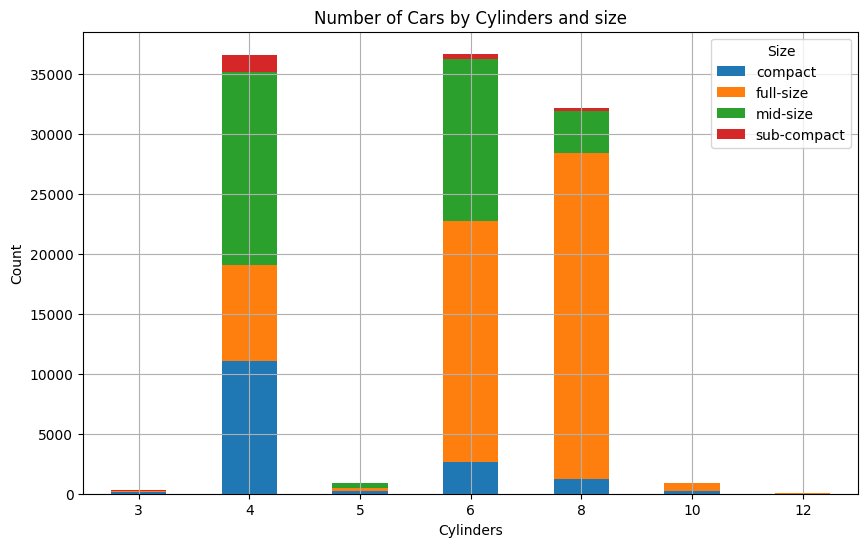

In [1293]:
c_filled = df_clean[df_clean["cylinders"].notna()]
c_filled["cylinders"] = c_filled["cylinders"].astype(int)
ct = pd.crosstab(c_filled["cylinders"], c_filled["size"])

ct.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.xlabel("Cylinders")
plt.ylabel("Count")
plt.title("Number of Cars by Cylinders and size")
plt.xticks(rotation=0)
plt.legend(title="Size")
plt.grid(True)
plt.show()

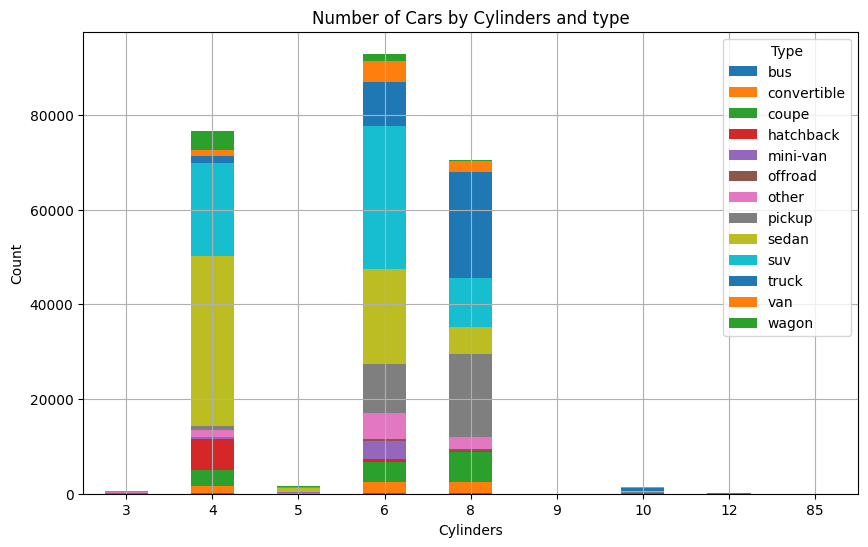

In [1294]:
ct = pd.crosstab(c_filled["cylinders"], c_filled["type"])
# Bar plot
ct.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.xlabel("Cylinders")
plt.ylabel("Count")
plt.title("Number of Cars by Cylinders and type")
plt.xticks(rotation=0)
plt.legend(title="Type")
plt.grid(True)
plt.show()

<font color="MidnightBlue">Here are two plots that show how often we see each number of cylinders in cars of a particular size and type. The second graph seems to be more usefull to me as it shows larger difference between distribution of number of cylindres. We can see that sedans most of the times in our dataset have 4 cylinders, SUVs 6, buses 8, pickups 8 etc, we can replace the missing cylinder value with the most common cylinders count for a type
 </font>

In [1295]:
most_common_cylinders = (
    c_filled.groupby("type")["cylinders"]
    .agg(lambda x: x.value_counts().idxmax())
)
most_common_cylinders_s = (
    c_filled.groupby("size")["cylinders"]
    .agg(lambda x: x.value_counts().idxmax())
)
most_common_cylinders

type
bus            8
convertible    6
coupe          8
hatchback      4
mini-van       6
offroad        6
other          6
pickup         8
sedan          4
suv            6
truck          8
van            6
wagon          4
Name: cylinders, dtype: int64

<font color="MidnightBlue"> I have calculated the most common cylinders for each type and size, and above is the exaple of the results (the largest number of buses have 8 cylinders, convertiables - 6 etc)</font>

In [1296]:
print(f"{df_clean["cylinders"].isna().sum() / df_clean.shape[0] * 100}% before replacing")
df_clean["cylinders"] = df_clean["cylinders"].fillna(df_clean["type"].map(most_common_cylinders))
df_clean["cylinders"]  = df_clean["cylinders"].fillna(df_clean["size"].map(most_common_cylinders_s))
print(f"{df_clean["cylinders"].isna().sum() / df_clean.shape[0] * 100}% after replacing")

41.79939063615606% before replacing
1.776957752187324% after replacing


<font color="MidnightBlue">We have significantly reduced the number of missing data after filling them with statistical inferences.
Now I can move to condition column which has the significant amount of NaNs. Since condition is closely related to the odometer value I will wrok on both columns and explore their relationship.
After exploring the year column, looking up the min and max values, I decided to break it down into the following bins
</font>

In [1297]:
bins = [0, 25000, 50000, 75000, 100000, 150000, 200000, np.inf]
labels = ["0-25k", "25-50k", "50-75k", "75-100k",
          "100-150k", "150-200k", "200k+"]

year_bins = [1900.0, 1910.00, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, np.inf ]
year_labels = [
    "1900-09",
    "1910-19",
    "1920-29",
    "1930-39",
    "1940-49",
    "1950-59",
    "1960-69",
    "1970-79",
    "1980-89",
    "1990-99",
    "2000-09",
    "2010-19",
    "2020+"
]
# Adding a column whihc will indicate the range into which a particular odo and year values will fall
df_clean["odo_bin"] = pd.cut(
    df_clean["odometer"],
    bins=bins,
    labels=labels
)

df_clean["year_bin"] = pd.cut(
    df_clean["year"],
    bins=year_bins,
    labels=year_labels
)
#checking how the data looks like here
df_clean[df_clean["condition"].isna()][["year_bin", "odo_bin", "title_status"]]
df_clean[df_clean["condition"].notna()][["year_bin", "odo_bin", "title_status", "condition"]]

#grouping by the combination of three factors and using the mode
most_common_conditions = (
    df_clean
    .groupby(["year_bin", "odo_bin", "title_status"])["condition"]
    .agg(lambda x: x.value_counts().idxmax() if not x.value_counts().empty else np.nan)
)
most_common_conditions


year_bin  odo_bin   title_status
1900-09   0-25k     clean                 NaN
                    parts only            NaN
          200k+     clean           excellent
                    parts only            NaN
1910-19   0-25k     clean                good
                                      ...    
2020+     100-150k  salvage               NaN
          150-200k  clean                fair
          200k+     clean                fair
                    missing               NaN
                    parts only        salvage
Name: condition, Length: 341, dtype: str

<font color="MidnightBlue">Here we can see that among the cars from 1900 - 09 y and 200K miles with clean titile status the condition is excellent. It's hard to evaluate to me how realistic it is. I'll leave it as it is for now</font>

In [1298]:
#A dataframe with a column new_condition which is inferend from statistic above
lookup = most_common_conditions.rename("new_condition").reset_index()
#merging lookup df with our main df
df_clean = df_clean.merge(
    lookup,
    on=["year_bin", "odo_bin", "title_status"],
    how="left"
)


In [1299]:
df_clean[["condition", "new_condition", "year_bin", "odo_bin", "title_status"]]
#looking up the resulting column, looks good.

,condition,new_condition,year_bin,odo_bin,title_status
0,good,good,2010-19,50-75k,clean
1,good,excellent,2000-09,50-75k,clean
2,good,good,2010-19,0-25k,clean
3,good,good,2010-19,25-50k,clean
4,excellent,excellent,2010-19,100-150k,clean
...,...,...,...,...,...
424372,good,good,2010-19,25-50k,clean
424373,good,good,2010-19,0-25k,clean
424374,good,good,2010-19,0-25k,clean
424375,good,good,2010-19,25-50k,clean


In [1300]:
#now we can replace missing values from the new column
print(f"{df_clean["condition"].isna().sum() / df_clean.shape[0] * 100}% missing condition befre replacing")
df_clean["condition"] = df_clean["condition"].fillna(df_clean["new_condition"])
df_clean.drop(columns="new_condition", inplace=True)
print(f"{df_clean["condition"].isna().sum() / df_clean.shape[0] * 100}% missing condition after replacing")

40.61600887889777% missing condition befre replacing
1.2778732117904599% missing condition after replacing


<font color="MidnightBlue"> Here we can see the significant drop in the number of missing values from 41% to 1% It's time to plot the percantage of missing values accross the entire dataset again.</font>

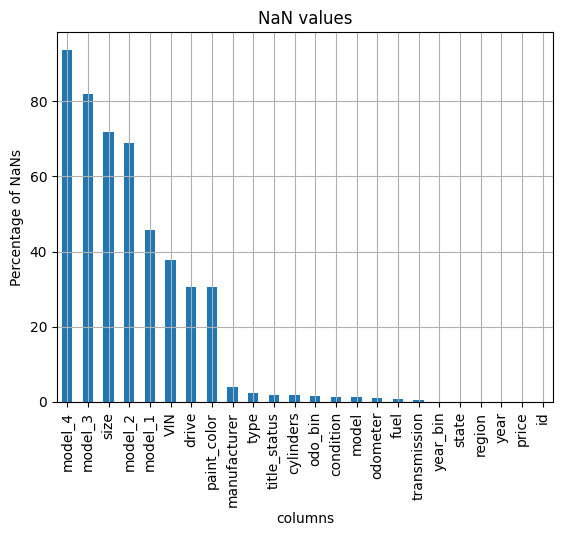

In [1301]:
nan_counts = df_clean.isna().sum().sort_values(ascending=False)
nan_counts = (nan_counts / df_clean.shape[0]) * 100
nan_counts.plot(kind='bar')
plt.title("NaN values")
plt.ylabel("Percentage of NaNs")
plt.xlabel("columns")
plt.grid(True)
plt.show()

<font color="MidnightBlue"> We will get rid of the engineered columns model_i and VIN since VIN is unnique for each car, I cannot really infer the paint color from the information I have, and I can work on the drive column with the same approach. </font>

In [1302]:
most_common_dr = (
    df_clean
    .groupby(["type", "manufacturer"])["drive"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
lookup = most_common_dr.rename("new_dr").reset_index()

df_clean = df_clean.merge(lookup, on=["type", "manufacturer"], how="left")
print(f"{df_clean["drive"].isna().sum() / df_clean.shape[0] * 100}% of missing drive values before filling up")
df_clean["drive"] = df_clean["drive"].fillna(df_clean["new_dr"])
df_clean.drop(columns="new_dr", inplace=True)
print(f"{df_clean["drive"].isna().sum() / df_clean.shape[0] * 100}% of missing drive values after filling up")

30.618058942873905% of missing drive values before filling up
2.913918520560728% of missing drive values after filling up


<font color="MidnightBlue">The last column to work on is size. Size can probably be infered from the type and the manufacturer of a car. I am not using model because model column is not consistent and messy</font>

In [1303]:
most_common_size= (
    df_clean
    .groupby(["type", "manufacturer"])["size"]
    .agg(lambda x: x.value_counts().idxmax() if not x.value_counts().empty else np.nan)
)
lookup = most_common_size.rename("new_size").reset_index()
df_clean = df_clean.merge(lookup, on=["manufacturer" , "type"], how="left")
df_clean[["new_size", "size", "manufacturer", "type"]]
print(f"{df_clean["size"].isna().sum() / df_clean.shape[0] * 100}% of missing size values before filling up")
df_clean["size"] = df_clean["size"].fillna(df_clean["new_size"])
df_clean.drop(columns="new_size", inplace=True)
print(f"{df_clean["size"].isna().sum() / df_clean.shape[0] * 100}% of missing size values after filling up")

71.73244544355609% of missing size values before filling up
4.561038887592871% of missing size values after filling up


<font color="MidnightBlue"> Here we again significantly reduced the number of missing values by making a statistical inference. Now when we have gotten rid of the missing values, I want to check the quality of existing data </font>

In [1304]:
# df_clean = df_clean.drop(columns=["id", "paint_color", "VIN", "model", "model_1", "model_2", "model_3", "model_4", "odo_bin", "year_bin"])


In [1305]:
# df_clean.isna().sum() / df_clean.shape[0] * 100

In [1306]:
# df_clean.dropna(inplace=True)
# print(f"The original number of entries: {len(df)}, number of entries after clean up {len(df_clean)}. ")
# print(f"{(len(df) - len(df_clean)) / len(df) * 100:.2f}% has been removed")

In [1307]:
df_clean["price"].sort_values()

318266             0
25847              0
25848              0
236015             0
236016             0
             ...    
36972     3009548743
90809     3024942282
256114    3024942282
354742    3736928711
316685    3736928711
Name: price, Length: 424377, dtype: int64

<font color="MidnightBlue"> We see strange numbers among prices, zeros and billions. Let's see how many of them are there before deciding what to do about the suspicious prices
 </font>

In [1308]:
zero_prices = (df_clean["price"] == 0).sum()

print("Number of zero prices:", zero_prices)
print(f"Percentage:, {zero_prices / len(df_clean) * 100}")

Number of zero prices: 32648
Percentage:, 7.693159619866298


In [1309]:
thresholds = [0, 100000, 500000, 1000000]

for t in thresholds:
    count = (df_clean["price"] > t).sum()
    print(f"Prices above {t}: {count} ({count/len(df_clean)*100:.3f}%)")

Prices above 0: 391729 (92.307%)
Prices above 100000: 652 (0.154%)
Prices above 500000: 68 (0.016%)
Prices above 1000000: 53 (0.012%)


In [1310]:
df[df["price"] > 1000000].head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
280,7315849335,birmingham,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
1838,7315961634,dothan,99999999,1993.0,ford,ranger,NaN,NaN,gas,99999.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,al
26075,7314964461,fresno / madera,1111111,2014.0,chevrolet,NaN,NaN,NaN,other,11.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,ca
29386,7305265540,humboldt county,1111111111,1999.0,ford,f350 super duty lariat,good,8 cylinders,diesel,149000.0,clean,automatic,NaN,rwd,full-size,pickup,white,ca
37409,7314053169,modesto,1111111111,2020.0,jeep,NaN,NaN,NaN,gas,1000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,ca


<font color="MidnightBlue"> Looks like the prices above 1 million are just random numbers, since our task is to find which featuires drive the price, I think it is better to delete these entries rather than filling them up with the means or medians. And the percantage of them is not high. Same is happening with the prices larger than 500000.   </font>

In [1311]:
df_clean = df_clean[df_clean["price"] <= 500000]
df_clean[df_clean["price"] <= 400000]["price"].sort_values()
#the maximum price here is  349999. I want to check this row to see how realistic it is
df_clean[df_clean["price"] >= 300000]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,size,type,paint_color,state,model_1,model_2,model_3,model_4,odo_bin,year_bin
43876,7314331466,palm springs,347999,2020.0,ferrari,f8 tributo,excellent,8,gas,3000.0,...,mid-size,coupe,NaN,ca,tributo,NaN,NaN,NaN,0-25k,2010-19
44903,7306488355,palm springs,349999,2020.0,ferrari,f8 tributo,excellent,8,gas,2800.0,...,mid-size,coupe,NaN,ca,tributo,NaN,NaN,NaN,0-25k,2010-19
87837,7316152381,"washington, dc",304995,2021.0,porsche,911,new,6.0,gas,22.0,...,compact,convertible,white,dc,NaN,NaN,NaN,NaN,0-25k,2020+
89513,7314029754,"washington, dc",304995,2021.0,porsche,911,new,6.0,gas,22.0,...,compact,convertible,white,dc,NaN,NaN,NaN,NaN,0-25k,2020+
112455,7314803400,south florida,470000,2016.0,NaN,hino 268,good,8.0,diesel,167268.0,...,NaN,truck,white,fl,268,NaN,NaN,NaN,150-200k,2010-19
132488,7316029298,east idaho,425000,1993.0,jeep,wrangler,excellent,6.0,gas,380.0,...,full-size,convertible,red,id,NaN,NaN,NaN,NaN,0-25k,1990-99
326262,7303420900,altoona-johnstown,400123,2003.0,NaN,any and all,fair,5,diesel,123321.0,...,full-size,pickup,blue,pa,and,all,NaN,NaN,100-150k,2000-09
358606,7312429759,nashville,449500,2019.0,ferrari,488 gtb,good,8.0,gas,500.0,...,mid-size,coupe,red,tn,gtb,NaN,NaN,NaN,0-25k,2010-19
397347,7313998757,winchester,304995,2021.0,porsche,911,new,6.0,gas,22.0,...,compact,convertible,white,va,NaN,NaN,NaN,NaN,0-25k,2020+


<font color="MidnightBlue">Data above 300000 looks more realistic, the elite cars are listed with these prices.
7% of data have price == 0. I'll remove low prices.
</font>

In [1312]:
count = df_clean[df_clean["price"] == 0]["price"].count()
print(f"Prices equal to 0: {count} ({count/len(df_clean)*100:.3f}%)")
df_clean = df_clean[df_clean["price"] > 100]


Prices equal to 0: 32648 (7.694%)


In [1313]:
df_clean[df_clean["price"] > 5]["price"].sort_values()
#I see some strange prices like 6. I'm gonna investigate what it is
df_clean[(df_clean["price"] > 100) & (df_clean["price"] <= 1000)]
#This segment of prices looks good.


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,size,type,paint_color,state,model_1,model_2,model_3,model_4,odo_bin,year_bin
338,7314941829,birmingham,199,2017.0,dodge,charger,good,4.0,gas,21737.0,...,full-size,sedan,NaN,al,NaN,NaN,NaN,NaN,0-25k,2010-19
729,7311491693,birmingham,199,2017.0,dodge,charger,good,4.0,gas,21737.0,...,full-size,sedan,NaN,al,NaN,NaN,NaN,NaN,0-25k,2010-19
906,7310466561,birmingham,199,2017.0,dodge,charger,good,4.0,gas,21737.0,...,full-size,sedan,NaN,al,NaN,NaN,NaN,NaN,0-25k,2010-19
1022,7308973381,birmingham,300,1999.0,saturn,sl,fair,4,gas,265000.0,...,mid-size,sedan,purple,al,NaN,NaN,NaN,NaN,200k+,1990-99
1124,7307861270,birmingham,199,2017.0,dodge,charger,good,4.0,gas,21737.0,...,full-size,sedan,NaN,al,NaN,NaN,NaN,NaN,0-25k,2010-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423841,7315020760,wyoming,600,2002.0,saturn,sl2,good,4,gas,150000.0,...,compact,sedan,red,wy,NaN,NaN,NaN,NaN,100-150k,2000-09
423856,7314353850,wyoming,500,2000.0,dodge,grand caravan,good,6,gas,187000.0,...,full-size,van,red,wy,caravan,NaN,NaN,NaN,150-200k,1990-99
424163,7306611738,wyoming,950,1995.0,ford,f-150,good,8,gas,209452.0,...,full-size,truck,NaN,wy,NaN,NaN,NaN,NaN,200k+,1990-99
424243,7303806527,wyoming,800,2000.0,cadillac,deville,excellent,8,gas,100000.0,...,full-size,coupe,white,wy,NaN,NaN,NaN,NaN,75-100k,1990-99


<font color="MidnightBlue">The mdeian price for the used cars is 15500, everything below 100 far away from the  median and looks unrealisitc in the table, they're all recorded as excellent cars in new condition with a two digit odometer number, so it looks like fake data. I am going to update the cell above to increase the threshhold from 0 to 100.

Now let's check odometer values.
</font>

In [1314]:
df_clean[df_clean["odometer"] <= 0]["odometer"].sort_values()

# there are no odometers with negative values
count = (df_clean["odometer"] <= 0).sum()
print(f"Odometer equal to 0: {count} ({count/len(df_clean)*100:.3f}%)")
df_clean  = df_clean[df_clean["odometer"] > 0]


Odometer equal to 0: 1049 (0.270%)


In [1315]:
df_clean["odometer"].quantile([0.95, 0.99, 0.995, 0.999, 1.0])

0.950      205868.0
0.990      280000.0
0.995      342000.0
0.999     1100000.0
1.000    10000000.0
Name: odometer, dtype: float64

<font color="MidnightBlue"> Here we can see that 99.5%.% have less or euqal  300000.0 miles,which is still a realistic number, 0.5% more than that. We can explore 0.5% of this data and delete all of it or partially
 </font>

In [1316]:
df_clean[df_clean["odometer"] > 500000]
#some of these numbers look pretty realisitc, I will increase the threshhold from 300_000 to 500_000
df_clean[df_clean["odometer"] > 500000]["odometer"].sort_values()
#the smallest for the threshhold of larger than 500_000 is 500100.0 the largest 10000000.0


241747      500100.0
242247      500100.0
239764      500100.0
392009      500776.0
241141      500850.0
             ...    
150688    10000000.0
151341    10000000.0
260600    10000000.0
406625    10000000.0
107229    10000000.0
Name: odometer, Length: 1131, dtype: float64

<font color="MidnightBlue">after some more data exploration, I came to conclusion that it is best to remove data where odometer is more than 500000. Even though some values in the range can be real but a big amount of data looks suspicios, and it is not a significant % of data to remove </font>

In [1317]:
df_clean = df_clean[df_clean["odometer"] < 500000]

<font color="MidnightBlue">My first idea was to remove region, VIN, paint color and id columns. But before removing the region and paint color, I want to see how they relate to the price. </font>

<Figure size 3000x2000 with 0 Axes>

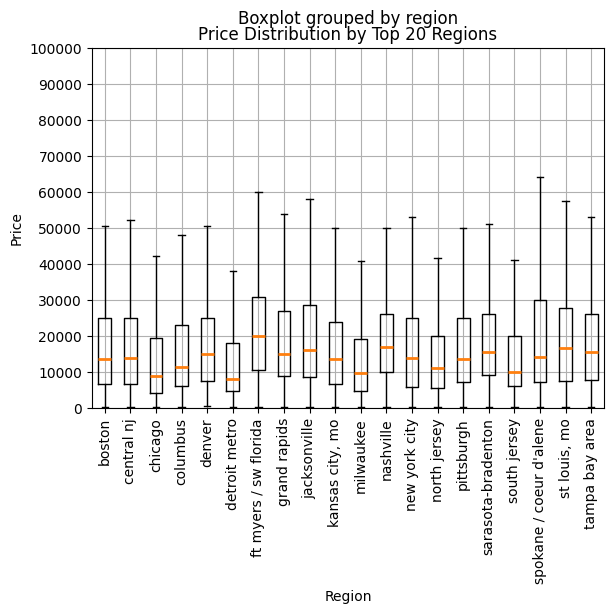

In [1318]:
top_regions = df_clean["region"].value_counts().head(20).index
plot_data = df_clean[df_clean["region"].isin(top_regions)]

plt.figure(figsize=(30, 20))

plot_data.boxplot(
    column="price",
    by="region",
    rot=90,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(color="black"),
    boxprops=dict(color="black"),
    showfliers=False
)

plt.ylim(0, 50000)

plt.xlabel("Region")
plt.ylabel("Price")
plt.title("Price Distribution by Top 20 Regions")
plt.yticks(range(0, 100001, 10000))




plt.show()



<font color="MidnightBlue"> I have too  many unique regions, so I picked up top 20, the most common region in the dataset. From the boxplot, we can see tha the median price falls somwhere between 10k and 20K. Spokane has the highest max price and and its upper quantile is higher than all other regions excpet for ft mayers/sw florida. Florida, in addition, has the highest mean and on eof the highest min price.  </font>

<Figure size 3000x2000 with 0 Axes>

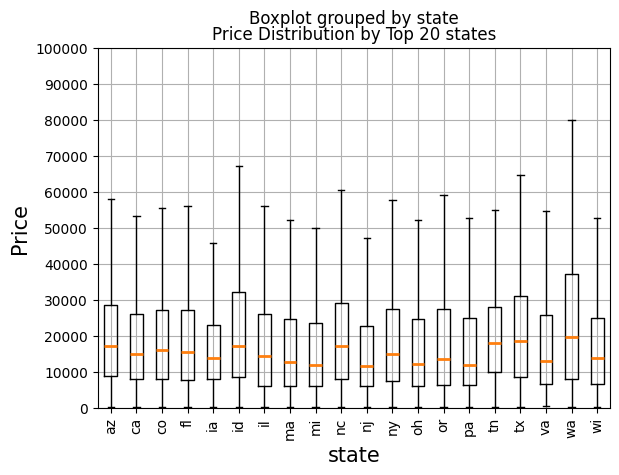

In [1319]:
top_regions = df_clean["state"].value_counts().head(20).index
plot_data = df_clean[df_clean["state"].isin(top_regions)]

plt.figure(figsize=(30, 20))

plot_data.boxplot(
    column="price",
    by="state",
    rot=90,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(color="black"),
    boxprops=dict(color="black"),
    showfliers=False
)

plt.ylim(0, 50000)

plt.xlabel("state", fontsize=15)
plt.ylabel("Price", fontsize=15)
plt.title("Price Distribution by Top 20 states")
plt.yticks(range(0, 100001, 10000))
plt.show()


<font color="MidnightBlue">If we look at the price distribution by state, than we see that Wancuver is the leader, it has the highest median, max, and upper qunatile, even the lower quantile is one of the highest. The state with cheapest prices for the used cars is Iowa. Although the median does not vary much between states or regions. </font>

<Figure size 1200x600 with 0 Axes>

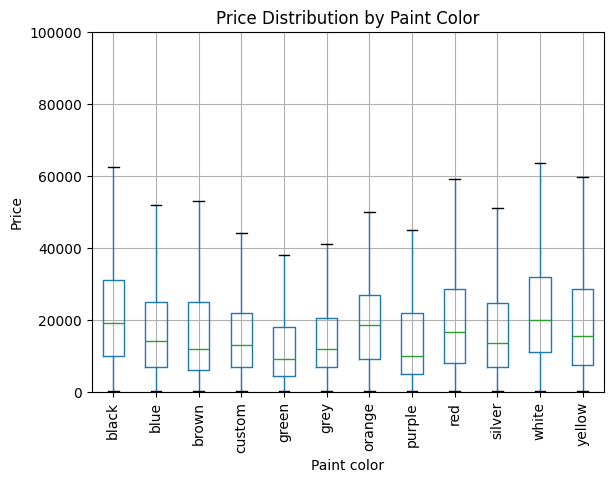

In [1320]:
plt.figure(figsize=(12, 6))

df_clean.boxplot(
    column="price",
    by="paint_color",
    showfliers=False
)

plt.xticks(rotation=90)
plt.ylim(0, 100000)
plt.xlabel("Paint color")
plt.ylabel("Price")
plt.title("Price Distribution by Paint Color")
plt.suptitle("")

plt.show()

In [1321]:
count = df_clean["paint_color"].isna().sum()
print(f"{count} missing paint colors ({count / len(df_clean) * 100:.2f}%)")

113347 missing paint colors (29.54%)


<font color="MidnightBlue">From this plot we can see that the white color had the higher upper percentile, followed by black cars and orange. Green have the lower marks for all measures, median , quantiles and max price. Since the color of a car does not depend on anything, it is hard to infere the missing values, and we have a substential percentage of missing color values, I will delete the entire column.</font>

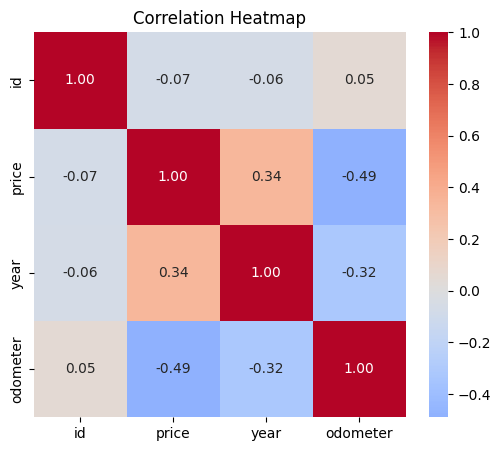

In [1322]:
corr = df_clean.select_dtypes(include="number").corr()
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

<font color="MidnightBlue">From the correlation heatmap ran on numerical numbers, we can see that, in general, correlation between price and other columns is pretty low. The highest correlation the price has is the odometer of the car, the correlation is negative which means the larger the odometer number is the lower the price whihc makes sense.  </font>

In [1323]:
df_clean = df_clean.drop(columns=["id", "paint_color", "VIN", "model", "model_1", "model_2", "model_3", "model_4", "odo_bin", "year_bin", "region"])

In [1324]:
df_clean.isna().sum() / df_clean.shape[0] * 100

price           0.000000
year            0.000000
manufacturer    3.598967
condition       0.452118
cylinders       1.678701
fuel            0.543584
odometer        0.000000
title_status    1.802741
transmission    0.395571
drive           2.656424
size            4.329392
type            2.360397
state           0.000000
dtype: float64

In [1325]:
df_clean.dropna(inplace=True)
print(f"The original number of entries: {len(df)}, number of entries after clean up {len(df_clean)}. ")
print(f"{(len(df) - len(df_clean)) / len(df) * 100:.2f}% has been removed")

The original number of entries: 426880, number of entries after clean up 352626. 
17.39% has been removed


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [1326]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 352626 entries, 0 to 424376
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         352626 non-null  int64  
 1   year          352626 non-null  float64
 2   manufacturer  352626 non-null  str    
 3   condition     352626 non-null  str    
 4   cylinders     352626 non-null  object 
 5   fuel          352626 non-null  str    
 6   odometer      352626 non-null  float64
 7   title_status  352626 non-null  str    
 8   transmission  352626 non-null  str    
 9   drive         352626 non-null  str    
 10  size          352626 non-null  str    
 11  type          352626 non-null  str    
 12  state         352626 non-null  str    
dtypes: float64(2), int64(1), object(1), str(9)
memory usage: 37.7+ MB


<font color= "MidnightBlue">OK, we see that cylinders column is not an integer, we have to convert into int</font>

In [1327]:
df_clean["cylinders"] = df_clean["cylinders"].astype(int)
df_clean.info()

<class 'pandas.DataFrame'>
Index: 352626 entries, 0 to 424376
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         352626 non-null  int64  
 1   year          352626 non-null  float64
 2   manufacturer  352626 non-null  str    
 3   condition     352626 non-null  str    
 4   cylinders     352626 non-null  int64  
 5   fuel          352626 non-null  str    
 6   odometer      352626 non-null  float64
 7   title_status  352626 non-null  str    
 8   transmission  352626 non-null  str    
 9   drive         352626 non-null  str    
 10  size          352626 non-null  str    
 11  type          352626 non-null  str    
 12  state         352626 non-null  str    
dtypes: float64(2), int64(2), str(9)
memory usage: 37.7 MB


In [1328]:
df_clean["manufacturer"].nunique()
df_clean["state"].nunique()

51

In [1329]:
df_clean["condition"].value_counts()

condition
good         176332
excellent    149455
like new      18580
fair           5884
new            1849
salvage         526
Name: count, dtype: int64

<font color="MidnightBlue">Now I will split the data reserving  30%  for testing.</font>

In [1330]:
X = df_clean.drop(columns="price")
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<font color="MidnightBlue">Here are 41 types of manufacturers and 51 state, I will run one-hot encoder over this column. It will drammatically increase the number of features but I think it is much better for the result than deleting the column, we can run PCA if needed later. All categorical features will go through the one-hot encoder. And condition will be ordinal. </font>

In [1331]:
condition_order = [
    ["salvage", "fair", "good", "excellent", "like new", "new"]
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore"),
            ["manufacturer", "fuel", "title_status", "transmission", "drive", "type", "state"]
        ),
        (
            "ordinal",
            OrdinalEncoder(categories=condition_order),
            ["condition"]
        ),
        (
            "scaler",
            StandardScaler(),
            ["cylinders", "odometer", "year"]
        )
    ]
)


In [1332]:
preprocesses = preprocessor.fit_transform(X_train)
selector = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select=5,
    direction="forward",
    scoring="neg_mean_squared_error",
    cv=5
)

selector.fit(preprocesses, y_train)




,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'neg_mean_squared_error'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,126
n_features_to_select_ n_features_to_select_: intThe number of features that were selected.,int64,np.int64(5)
"support_ support_: ndarray of shape (n_features,), dtype=boolThe mask of selected features.","ndarray[bool](126,)","[False,False,False,..., True, True, True]"


<font color="MidnightBlue">I need to decide which model to use, I will start with a simple Linear regression from sklearn </font>

In [1333]:
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("linreg", LinearRegression()),
    ]
)
pipe.fit(X_train, y_train)
pred_train = pipe.predict(X_train)
train_mse = mean_squared_error(y_train, pred_train)
train_mae = mean_absolute_error(y_train, pred_train)
print(f"Train MSE: {train_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
pred_test = pipe.predict(X_test)
test_mse = mean_squared_error(y_test, pred_test)
test_mae = mean_absolute_error(y_test, pred_test)
print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f}")


Train MSE: 86043884.19
Train MAE: 5984.31
Test MSE: 88052276.83
Test MAE: 6024.76


<font color="MidnightBlue">
## Simple Linear Regression results:

Train MSE: 86041970.10

Train MAE: 5984.15

Test MSE: 88050201.19

Test MAE: 6024.60
</font>

<font color="MidnightBlue">The error for the simple linear regression is too high, which mean the model is underfit. I will need to increase its complexity. I will use polynomial features to do that. </font>

In [1334]:
#I need to see how many features I end up with after transformers
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
print(X_train_transformed.shape)

(246838, 126)


In [1335]:
min_test_err = np.inf
best_mae = 0
best_degree = 0

pipe = Pipeline(
[
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("linreg", LinearRegression()),
]
)
pipe.fit(X_train, y_train)
pred_test = pipe.predict(X_test)
train_mse = mean_squared_error(y_train, pred_train)
train_mae = mean_absolute_error(y_train, pred_train)
test_mse = mean_squared_error(y_test, pred_test)
test_mae = mean_absolute_error(y_test, pred_test)

print(f"Train MSE: {train_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f}")



Train MSE: 86043884.19
Train MAE: 5984.31
Test MSE: 58363488.17
Test MAE: 4478.69


In [1336]:
alphas = [10, 20, 30]
min_test_err = np.inf
best_test_mae = 0
best_alfa = 0
best_degree = 0

for a in alphas:
    pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("poly", PolynomialFeatures(degree=2)),
        ("ridge", Ridge(alpha=a)),
    ]
    )
    pipe.fit(X_train, y_train)
    pred_test = pipe.predict(X_test)

    train_mse = mean_squared_error(y_train, pred_train)
    train_mae = mean_absolute_error(y_train, pred_train)

    test_mse = mean_squared_error(y_test, pred_test)
    test_mae = mean_absolute_error(y_test, pred_test)

    if test_mse < min_test_err:
        min_test_err = test_mse
        best_alfa = a
        best_test_mae = test_mae


print(f" Test MSE {min_test_err:,.2f}")
print(f" Test MAE {best_test_mae:,.2f}")

print("best alfa ", best_alfa)

 Test MSE 56,547,433.76
 Test MAE 4,436.72
best alfa  20


<font color="MidnightBlue">I was trying to run poly with degrees 2 and 3, but it took too long, so I will stick with the minnimal degree 2 and I will try to compare it with the simple linreg and regularized.

The best model turned out to be the one with the ridge regularisation out of the ones I have tried. Maybe higher polynomial degrees would work better but I have limitted time.

Test MSE 56,547,433.76
Test MAE 4,436.72
best alfa  20


</font>

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [1337]:
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("poly", PolynomialFeatures(degree=2)),
        ("ridge", Ridge(alpha=20)),
    ]
    )
pipe.fit(X_train, y_train)
pred_test = pipe.predict(X_test)
pipe.fit(X_train, y_train)

train_mse = mean_squared_error(y_train, pipe.predict(X_train))
train_mae = mean_absolute_error(y_train, pipe.predict(X_train))

test_mse = mean_squared_error(y_test, pipe.predict(X_test))
test_mae = mean_absolute_error(y_test, pipe.predict(X_test))
print(f" Train MSE {train_mse:,.2f}")
print(f" Train MAE {train_mae:,.2f}")
print(f" Test MSE {test_mse:,.2f}")
print(f" Test MAE {test_mae:,.2f}")


 Train MSE 54,275,647.61
 Train MAE 4,381.76
 Test MSE 56,547,433.76
 Test MAE 4,436.72


<font color="MidnightBlue">Here we can see that the train error is smaller then the test error, which is expected, it means our model is not overfitted, but maybe underfitted and can be fine tuned further.




</font>

In [1338]:
median_price = df_clean["price"].median()
mean_price = df_clean["price"].mean()

print(f"Overall median price: ${median_price:,.2f}")
print(f"Model error as percentage of median price: {test_mae / median_price * 100:.2f}%")
print(f"Model error as percentage of mean price: {test_mae / mean_price * 100:.2f}%")


Overall median price: $15,800.00
Model error as percentage of median price: 28.08%
Model error as percentage of mean price: 23.34%


In [1339]:
baseline_pred = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)

print(f"Baseline MAE: {baseline_mae:,.2f}")
print(f"Baseline MSE: {baseline_mse:,.2f}")

Baseline MAE: 11,516.47
Baseline MSE: 220,840,824.94


<font color="MidnightBlue"> Although, our model has a pretty high margin of error 23 % it is still significantly  better than the baseline. </font>

In [1340]:
pipe.score(X_test, y_test)

0.7439447909148671

<font color="MidnightBlue"> 0.74 is not a bad score but not ideal </font>

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [1341]:
from sklearn.inspection import permutation_importance
important = permutation_importance(pipe, X_test, y_test,
                           n_repeats=30,
                           random_state=0)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": important.importances_mean,
    "std": important.importances_std
})

In [1342]:
importance_df

,feature,importance,std
0,year,0.370665,0.002211
1,manufacturer,0.150673,0.001642
2,condition,0.006870,0.000352
3,cylinders,0.102216,0.001094
4,fuel,0.082042,0.000855
5,odometer,0.251452,0.001700
6,title_status,0.009290,0.000354
7,transmission,0.033777,0.000582
8,drive,0.051186,0.000789
9,size,0.000000,0.000000


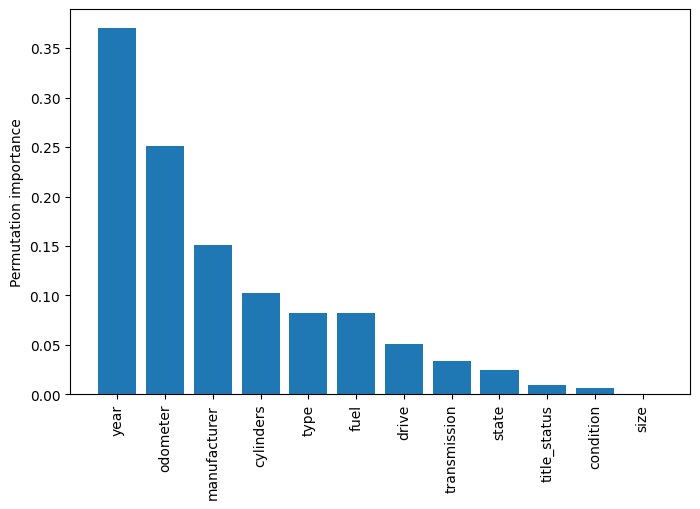

np.float64(0.3777511944118602)

In [1343]:
importance_df = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=90)
plt.ylabel("Permutation importance")
plt.show()
df_clean["price"].corr(df_clean["year"])

<font color="MidnightBlue">From this graph we see that the most important feature that influences the price is the year of a used car. The correlation is positive, so the higher the year, the higher the price of a car. Odometer is 10 times less important than the year. The third place in the importance is taken by the manufacturer. And the three least important features are title status, condition and size, the last one has 0 or close to zero importance.  </font>

<Axes: title={'center': 'price'}, xlabel='manufacturer'>

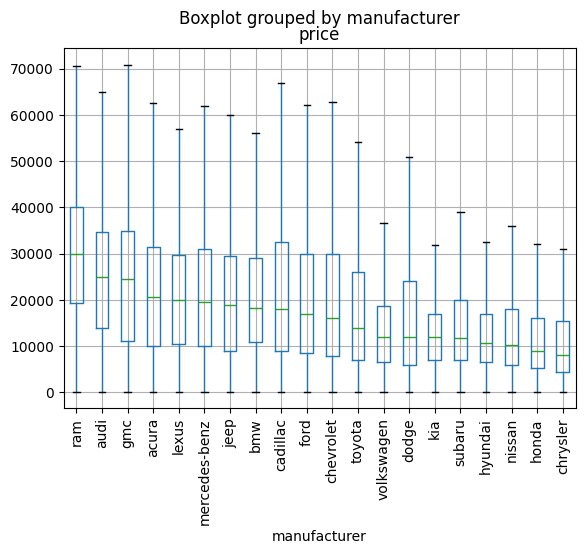

In [1344]:
top_manufacturers = (
    df_clean["manufacturer"]
    .value_counts()
    .head(20)
    .index
)
plot_data = df_clean[
    df_clean["manufacturer"].isin(top_manufacturers)
]

order = (
    plot_data.groupby("manufacturer")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)



plot_data["manufacturer"] = pd.Categorical(
    plot_data["manufacturer"],
    categories=order,
    ordered=True
)

plot_data.boxplot(
    column="price",
    by="manufacturer",
    rot=90,
    showfliers=False
)

<font color="MidnightBlue">

Since manufacturer is the third most important feature influencing vehicle price, I visualized the price distribution for the 20 most common manufacturers.

RAM is positioned at the top of the distribution, with the highest median price and the highest overall price distribution. Audi and GMC follow, with GMC exhibiting a wider spread of prices than Audi, indicating greater variability in vehicle prices.

At the lower end of the distribution are Chrysler and Honda, which have the lowest median prices. Kia also falls near the lower end and is followed by Subaru. Although Subaru has a similar or lower median price to Kia, its price distribution is wider and its maximum price is higher, suggesting that some Subaru models can be more expensive than Kia models.

</font>

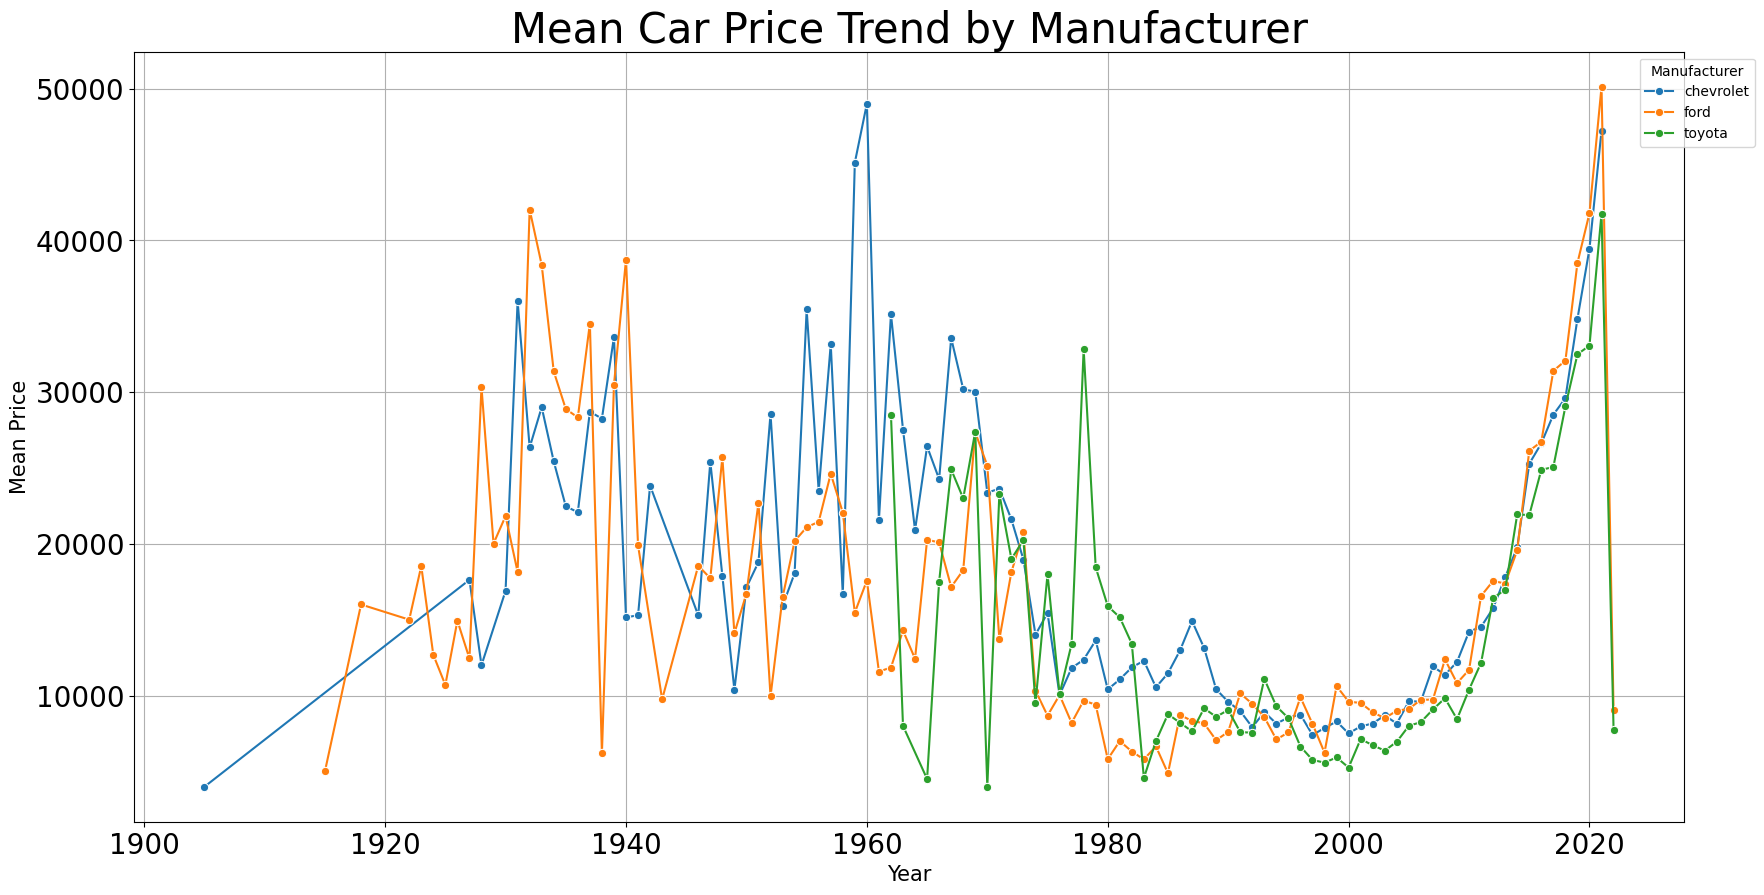

In [1375]:
top_manufacturers = (
    df_clean["manufacturer"]
    .value_counts()
    .head(3)
    .index
)

plot_data = df_clean[
    df_clean["manufacturer"].isin(top_manufacturers)
]

price_trend = (
    plot_data
    .groupby(["year", "manufacturer"])["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(20, 10))
sns.lineplot(
    data=price_trend,
    x="year",
    y="price",
    hue="manufacturer",
    marker="o"
)

plt.ylabel("Mean Price", fontsize=15)
plt.xlabel("Year", fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title("Mean Car Price Trend by Manufacturer", fontsize=30)
plt.grid(True)
plt.legend(title="Manufacturer", bbox_to_anchor=(1.05, 1))
plt.show()

<font color="MidnightBlue">I decided to plot out how the price changes for each manufacturer by a year. To avoid unreadability, I selcted only 3 most common manufacturers from the dataset. It is interesting to see that the price of a retro Chevrolet is high if the car is from 60s.  And among retro Fords, the ones that are in 30s are valued more. The price of older cars start to drop between 80s and 2000s. And after 200 the prices of all three makes exhibit a similar pattern of growth.   </font>

In [1373]:
df_clean[(df_clean["manufacturer"].isin(top_manufacturers)) & (df_clean["year"] >= 2021)]["price"]

274030       299
110394       299
137604       651
52210        684
321260       757
           ...  
43679     129500
245556    129500
41638     129500
30621     129500
53406     129500
Name: price, Length: 589, dtype: int64

<font color="MidnightBlue">The drop around the 2021 looked suspicious. to me, I looked it up. It can be that we don't have enough data from these years, as well from the retro years and it explains its chopiness. And the data might not represent true values, I see some three-digit numbers among the cars newer than 2021. </font>

### Next steps and recommendations:


1) The year of a car is more important than its milage.
2) The next important feature is a manufacturer. RAM and GMC can be sold as high as 70,000. At least 75% of RAM can be sold for more than 20,000. And 75% of Audi can be sold for 15,000. The hightest price for audi is however lower than RAM and GMC, it is around 65,000. Cadillacs can be sold for the price above 65,000, however, 75% of them are sold at the price lower than 35,000.
3) If buying a Chrysler car than consider that it most likely will not be sold for more than approximately 31,000 And 75% of them are sold for lower than 15,000. When the median price is less than 10,000.
4) The paint color did not participate in the importance scaling, but the analyses has shown that white and black cars tend to be sold higher than other colors. The third place take the orange. And green cars have the lowest price distribution.